# NLP Triage Model - IMPACT Project
Generates a multi-lingual Pan-India dataset locally and trains Category/Severity predictors.

In [2]:
import pandas as pd
import random
import os

categories = ['Water', 'Roads', 'Sanitation', 'Electricity', 'Health']
severities = ['Low', 'Medium', 'High', 'Urgent']

# Vastly expanded templates for Pan-India civic complaints
# Mix of pure English, pure Hindi (transliterated), and Hinglish
templates = {
    'Water': [
        ("No water supply since yesterday morning", "High"),
        ("Paani nahi aa raha hai kab se", "High"),
        ("Water pipe broken and leaking heavily", "Urgent"),
        ("Pipe toot gaya hai water leak ho raha hai", "Medium"),
        ("Jal aapurti band hai", "High"),
        ("Drinking water is coming yellow and dirty", "High"),
        ("Peene ka paani ganda aur peela aa raha hai", "High"),
        ("Low water pressure, unable to fill overhead tanks", "Low"),
        ("Tanker not arrived yet", "Medium"),
        ("Water tank is overflowing and wasting water", "Medium"),
        ("Sewer water mixing with drinking water line", "Urgent"),
        ("Ganda paani aa raha hai nal se", "High"),
        ("No water pressure at all", "Medium"),
        ("Water meter is leaking", "Low")
    ],
    'Roads': [
        ("Large pothole causing daily accidents", "Urgent"),
        ("Bada gaddha hai road par accident ho rahe hain", "High"),
        ("Traffic light is completely dead", "Urgent"),
        ("Traffic signal kharab hai jam laga hai", "High"),
        ("Road paving left incomplete by municipal contractors", "Medium"),
        ("Road par construction material pada hai", "Low"),
        ("Speed breaker is too high, damaging cars", "Low"),
        ("Sadak puri tarah se tuti hui hai", "Medium"),
        ("Manhole cover is missing on the main road", "Urgent"),
        ("Gutter ka dhakkan gayab hai", "Urgent"),
        ("Footpath is broken and risky for pedestrians", "Low"),
        ("Street is heavily waterlogged after rain", "High"),
        ("Baarish ke baad poori sadak par paani bhar gaya hai", "High")
    ],
    'Sanitation': [
        ("Garbage has not been collected for an entire week", "Medium"),
        ("Kachra uthaya nahi gaya hai bohot din se", "Medium"),
        ("Garbage dump is overflowing and smelling terribly", "High"),
        ("Kachre ke dher se bohot gandi badboo aa rahi hai", "High"),
        ("Dead animal laying on the street", "Urgent"),
        ("Janwar mara pada hai bimari fail sakti hai", "Urgent"),
        ("Public toilet is incredibly dirty and unusable", "High"),
        ("Sulabh shauchalay bohot ganda hai", "High"),
        ("Drain is blocked and overflowing onto the street", "Urgent"),
        ("Nali jam ho gayi hai aur paani raste par aa raha hai", "Urgent"),
        ("People are dumping waste in the empty plot", "Medium"),
        ("Khali zameen par log kachra fenk rahe hain", "Medium"),
        ("Sweeper is not coming regularly", "Low")
    ],
    'Electricity': [
        ("Power cut since morning, please fix", "Medium"),
        ("Subah se bijli nahi hai", "Medium"),
        ("Sparking from the electric pole outside", "Urgent"),
        ("Bijli ke khambhe se aag nikal rahi hai", "Urgent"),
        ("Voltage fluctuation is destroying home appliances", "High"),
        ("Voltage bahut upar niche ho raha hai", "High"),
        ("Transformer blast nearby, completely dark", "Urgent"),
        ("Transformer jal gaya hai", "Urgent"),
        ("Frequent power cuts ruining my work from home", "Medium"),
        ("Baar baar light jaa rahi hai", "Medium"),
        ("Live wire fallen on the street", "Urgent"),
        ("Zameen par nangi wire giri hui hai", "Urgent"),
        ("Street light has been on during the daytime for days", "Low")
    ],
    'Health': [
        ("Mosquitoes breeding in stagnant water plot", "Medium"),
        ("Macchar paida ho rahe hain ruke hue paani me", "Medium"),
        ("Local government clinic has no doctor available", "High"),
        ("Sarkari hospital me koi doctor nahi baitha hai", "High"),
        ("Stray dogs are aggressive and biting residents", "Urgent"),
        ("Kutte kaat rahe hain mohalle me", "Urgent"),
        ("Dengue and Malaria cases increasing rapidly", "Urgent"),
        ("Dengue fail raha hai fogging karwaiye", "Urgent"),
        ("Medical waste dumped on the street", "High"),
        ("Hospital ka kachra road par feka hai", "High"),
        ("Pigs are roaming freely in residential area", "Low"),
        ("Suar ghoom rahe hain colony me", "Low")
    ]
}

data = []
num_samples = 150000 
print(f"Generating {num_samples} Pan-India multi-lingual civic complaint records...")

for i in range(num_samples):
    cat = random.choice(categories)
    template, default_sev = random.choice(templates[cat])
    
    # 15% probability of differing severity to make the model learn context not just memorization
    sev = default_sev if random.random() > 0.15 else random.choice(severities)
    
    text = template
    
    # Text formatting augmentations
    if random.random() > 0.6: text = text.lower()
    if random.random() > 0.9: text = text.upper()
    
    # Introducing minor typos (hinglish variations)
    if random.random() > 0.8:
        val = random.random()
        if val > 0.5:
            text = text.replace("water", "watre").replace("electricity", "electricty")
        else:
            text = text.replace("hai", "h").replace("raha", "rha")
            
    data.append([text, cat, sev])

df = pd.DataFrame(data, columns=['description', 'category', 'severity'])
df.to_csv('civic_complaints.csv', index=False)
print("Successfully saved to ./civic_complaints.csv")
df.head()

Generating 150000 Pan-India multi-lingual civic complaint records...
Successfully saved to ./civic_complaints.csv


,description,category,severity
0,sewer water mixing with drinking water line,Water,Urgent
1,water tank is overflowing and wasting water,Water,Medium
2,Stray dogs are aggressive and biting residents,Health,Urgent
3,DENGUE AND MALARIA CASES INCREASING RAPIDLY,Health,Medium
4,Voltage bahut upar niche ho raha hai,Electricity,Urgent


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import joblib

X = df['description']
y_cat = df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

# Vectorizer handles text conversion
vectorizer = TfidfVectorizer(max_features=5000, sublinear_tf=True, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Category Model
cat_model = LogisticRegression(max_iter=1000)
cat_model.fit(X_train_vec, y_train)

print("=== Category Classification Report ===")
print(classification_report(y_test, cat_model.predict(X_test_vec)))

=== Category Classification Report ===
              precision    recall  f1-score   support

 Electricity       1.00      1.00      1.00      6010
      Health       1.00      1.00      1.00      6037
       Roads       1.00      1.00      1.00      6019
  Sanitation       1.00      1.00      1.00      5984
       Water       1.00      1.00      1.00      5950

    accuracy                           1.00     30000
   macro avg       1.00      1.00      1.00     30000
weighted avg       1.00      1.00      1.00     30000



In [4]:
y_sev = df['severity']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y_sev, test_size=0.2, random_state=42)

# Train Severity model
sev_model = RandomForestClassifier(n_estimators=100, random_state=42)
sev_model.fit(X_train_vec, y_train_s)

print("=== Severity Classification Report ===")
print(classification_report(y_test_s, sev_model.predict(X_test_vec)))

=== Severity Classification Report ===
              precision    recall  f1-score   support

        High       0.89      0.91      0.90      8880
         Low       0.89      0.79      0.84      4677
      Medium       0.88      0.88      0.88      7425
      Urgent       0.89      0.91      0.90      9018

    accuracy                           0.89     30000
   macro avg       0.89      0.87      0.88     30000
weighted avg       0.89      0.89      0.89     30000



In [5]:
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(cat_model, 'category_model.pkl')
joblib.dump(sev_model, 'severity_model.pkl')
print('Models successfully exported locally in the ML Model folder!')
# You can now seamlessly load these into your IMPACT application.

Models successfully exported locally in the ML Model folder!


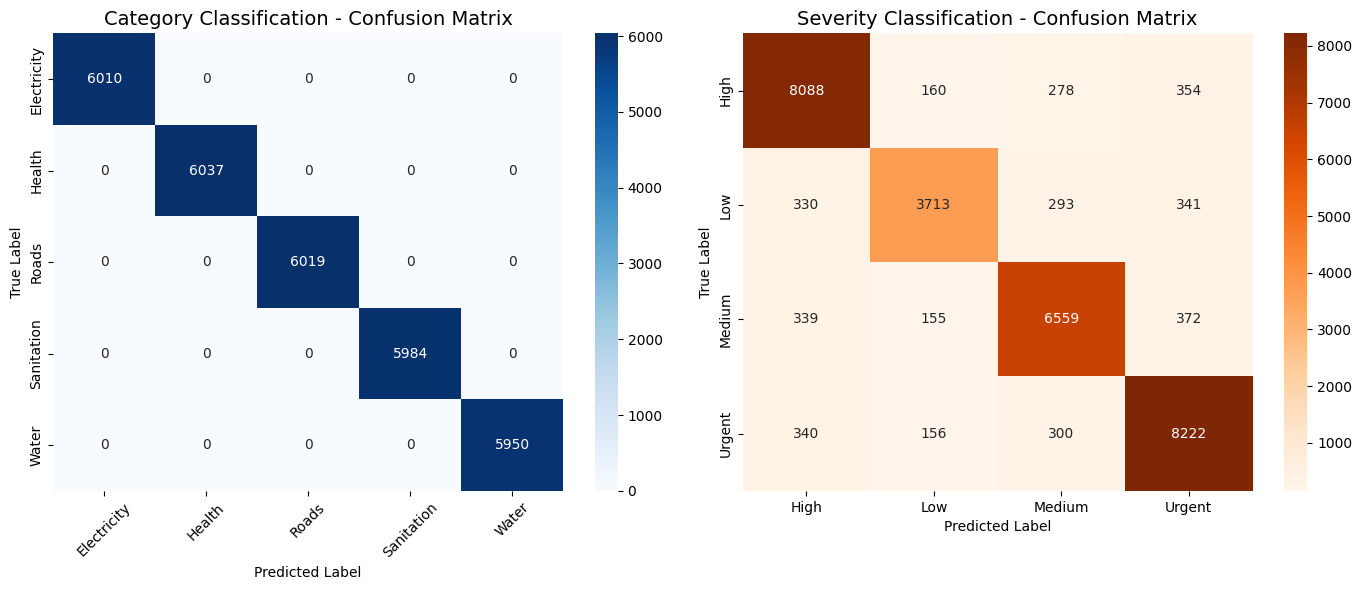

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import joblib

# 1. Re-load the Data & recreating identical test splits natively
df = pd.read_csv('civic_complaints.csv')
X = df['description']
y_cat = df['category']
y_sev = df['severity']

# random_state=42 ensures we test on the exact same records the model was evaluated on initially
_, X_test, _, y_test_cat = train_test_split(X, y_cat, test_size=0.2, random_state=42)
_, _, _, y_test_sev = train_test_split(X, y_sev, test_size=0.2, random_state=42)

# 2. Load the exported Pretrained Models
vectorizer = joblib.load('tfidf_vectorizer.pkl')
cat_model = joblib.load('category_model.pkl')
sev_model = joblib.load('severity_model.pkl')

# Transform test data using the loaded vectorizer
X_test_vec = vectorizer.transform(X_test)

# 3. Create Visualizations
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- Category Model Visualization ---
y_pred_cat = cat_model.predict(X_test_vec)
cm_cat = confusion_matrix(y_test_cat, y_pred_cat)

sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=cat_model.classes_, 
            yticklabels=cat_model.classes_)
ax[0].set_title('Category Classification - Confusion Matrix', fontsize=14)
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')
ax[0].tick_params(axis='x', rotation=45)

# --- Severity Model Visualization ---
y_pred_sev = sev_model.predict(X_test_vec)
cm_sev = confusion_matrix(y_test_sev, y_pred_sev)

sns.heatmap(cm_sev, annot=True, fmt='d', cmap='Oranges', ax=ax[1],
            xticklabels=sev_model.classes_, 
            yticklabels=sev_model.classes_)
ax[1].set_title('Severity Classification - Confusion Matrix', fontsize=14)
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


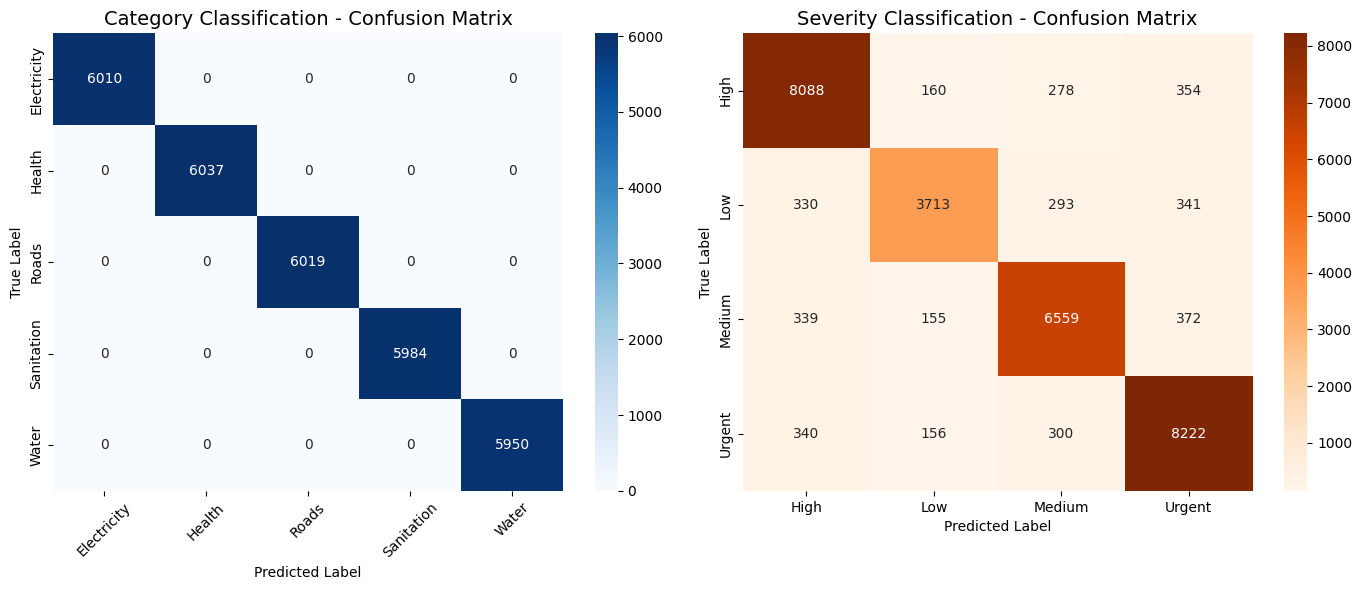

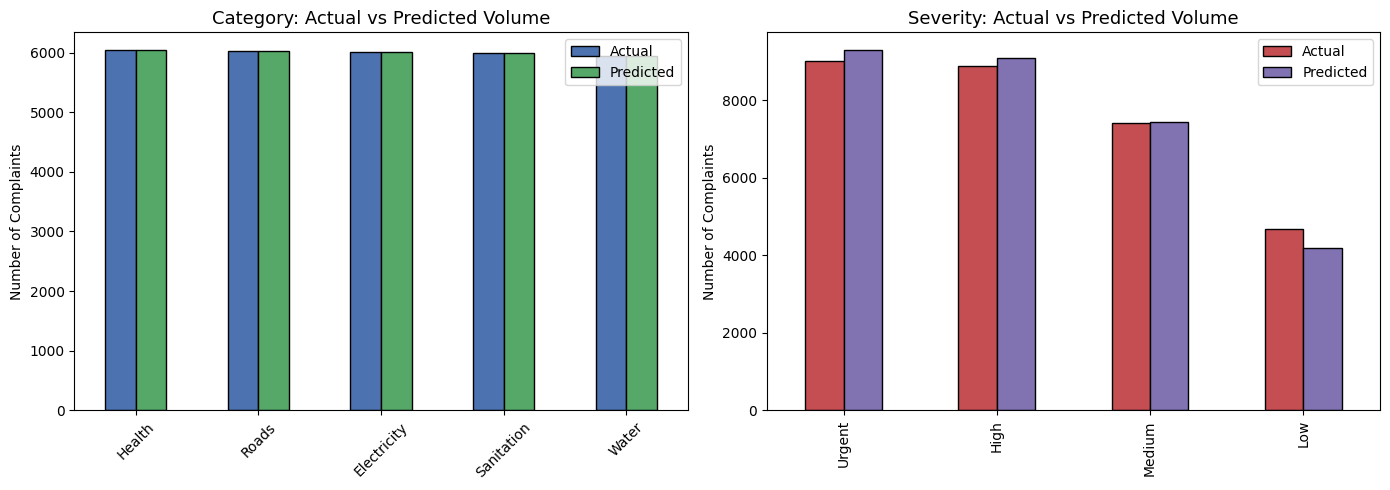

C:\Users\taher\AppData\Local\Temp\ipykernel_22964\2682437668.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances, y=top_features, palette='rocket')


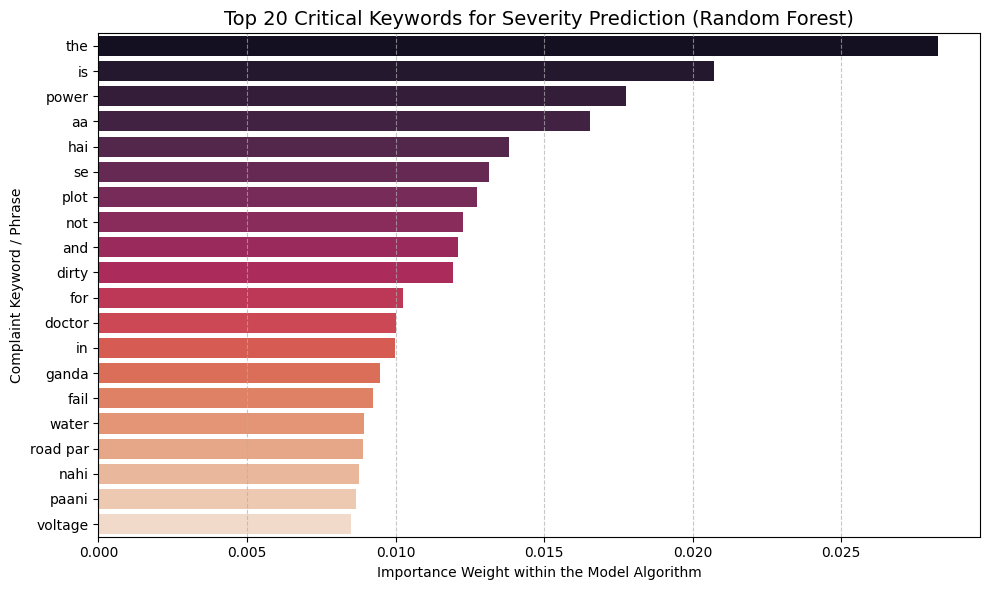

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import joblib

# 1. Re-load the Data & Recreate Exact Test Splits
df = pd.read_csv('civic_complaints.csv')
X = df['description']
y_cat = df['category']
y_sev = df['severity']

_, X_test, _, y_test_cat = train_test_split(X, y_cat, test_size=0.2, random_state=42)
_, _, _, y_test_sev = train_test_split(X, y_sev, test_size=0.2, random_state=42)

# 2. Load Models
vectorizer = joblib.load('tfidf_vectorizer.pkl')
cat_model = joblib.load('category_model.pkl')
sev_model = joblib.load('severity_model.pkl')
X_test_vec = vectorizer.transform(X_test)

y_pred_cat = cat_model.predict(X_test_vec)
y_pred_sev = sev_model.predict(X_test_vec)

# =========================================================================
# GRAPH 1 & 2: CONFUSION MATRICES (Heatmaps)
# =========================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

cm_cat = confusion_matrix(y_test_cat, y_pred_cat)
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=cat_model.classes_, yticklabels=cat_model.classes_)
ax[0].set_title('Category Classification - Confusion Matrix', fontsize=14)
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')
ax[0].tick_params(axis='x', rotation=45)

cm_sev = confusion_matrix(y_test_sev, y_pred_sev)
sns.heatmap(cm_sev, annot=True, fmt='d', cmap='Oranges', ax=ax[1], xticklabels=sev_model.classes_, yticklabels=sev_model.classes_)
ax[1].set_title('Severity Classification - Confusion Matrix', fontsize=14)
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# =========================================================================
# GRAPH 3: CLASS DISTRIBUTION (Actual vs Predicted)
# =========================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Category Distribution
cat_counts = pd.DataFrame({'Actual': y_test_cat.value_counts(), 'Predicted': pd.Series(y_pred_cat).value_counts()}).fillna(0)
cat_counts.plot(kind='bar', ax=ax[0], color=['#4C72B0', '#55A868'], edgecolor='black')
ax[0].set_title('Category: Actual vs Predicted Volume', fontsize=13)
ax[0].set_ylabel('Number of Complaints')
ax[0].tick_params(axis='x', rotation=45)

# Severity Distribution
sev_counts = pd.DataFrame({'Actual': y_test_sev.value_counts(), 'Predicted': pd.Series(y_pred_sev).value_counts()}).fillna(0)
sev_counts.plot(kind='bar', ax=ax[1], color=['#C44E52', '#8172B2'], edgecolor='black')
ax[1].set_title('Severity: Actual vs Predicted Volume', fontsize=13)
ax[1].set_ylabel('Number of Complaints')

plt.tight_layout()
plt.show()

# =========================================================================
# GRAPH 4: FEATURE IMPORTANCE (What keywords trigger the Severity model?)
# =========================================================================
importances = sev_model.feature_importances_
feature_names = vectorizer.get_feature_names_out()

# Sort to get Top 20 most important keywords
indices = np.argsort(importances)[::-1][:20]
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, palette='rocket')
plt.title('Top 20 Critical Keywords for Severity Prediction (Random Forest)', fontsize=14)
plt.xlabel('Importance Weight within the Model Algorithm')
plt.ylabel('Complaint Keyword / Phrase')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
